# EPOCH 5th Datathon — 최종 제출 노트북 (YouTube Rising Channel)

**목표**: 기준일 D = 2026-09-01 시점에서, 이후 26일(본선 정답 구간 09-01 ~ 09-26) 동안 성장 점수
`growth = log1p(future_med) − log1p(past_med)` 가 같은 기준일 내 상위 20%에 드는 채널(Rising)을 예측한다.
평가지표는 **PR-AUC** (무작위 = 0.20). 순위만 중요하다.

**파이프라인 요약**
1. `make_features(D)` — 기준일 이전(`published_at < D`) 정보만으로 채널별 피처 23개 생성
2. `make_labels(D, FUT=26)` — 공식 라벨 규칙을 그대로 재현해, 본선과 같은 26일 창으로 추가 학습 라벨 생성
3. 검증 — **시간 누수 없는 분리**: 라벨 창이 08-25 이전에 끝나는 기준일(≤ 07-30)로 학습 → 공식 08-25 라벨로 평가
4. 최종 점수 = rank(로지스틱 회귀 확률) + rank(−log past_med) 의 평균 순위

> 실행 환경: Python 3, duckdb, pandas, numpy, scikit-learn, matplotlib. 데이터 경로 `../data/raw/epoch_data`.

In [1]:
import os, glob, platform, warnings
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 50)

RAW = '../data/raw/epoch_data'
D = '2026-09-01'          # 본선 기준일
FUT = 26                  # 본선 정답 구간 길이 (일)
SEED = 42

con = duckdb.connect()
for p in sorted(glob.glob(f'{RAW}/*.csv')):
    name = os.path.splitext(os.path.basename(p))[0]
    con.sql(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_csv('{p}', header=true, auto_detect=true)")

con.sql("SELECT MIN(published_at), MAX(published_at), COUNT(*) FROM video_5d_views").df()

,min(published_at),max(published_at),count_star()
0,2026-07-10 08:39:51,2026-08-31 23:59:27,31524


## 1. 피처 — `make_features(Dref)`

모든 피처는 `published_at < Dref`(영상) 또는 `collected_at < Dref`(채널 스냅샷) 레코드만 사용한다.
08-11 / 08-25 / 09-01 어느 기준일에 넣어도 같은 방식으로 동작한다.

| 그룹 | 피처 | 의도 |
|---|---|---|
| 과거 수준 | `log_past_med`, `log_q10`, `log_q90` | 라벨이 `log(미래) − log(과거)`이므로 과거 수준이 낮을수록 평균 회귀로 Rising이 되기 쉬움 |
| 최근 모멘텀 | `mom_7`, `mom_14`, `mom_old`, `trend_slope` | 최근 영상이 과거 대비 잘 나오는지 |
| 변동성 | `log_view_std` | 가끔 크게 터지는 채널은 미래 중앙값이 튈 여지가 큼 |
| 업로드 활동 | `n_long_7/14/28`, `n_short_14`, `short_ratio`, `days_since_long`, `avg_dur` | 미래 구간에 롱폼이 없으면 future=0 → 자동으로 하위 |
| 반응 | `like_rate`, `comment_rate`, `log_short_med_rel` | 시청자 반응 강도 |
| 게임 | `n_games`, `has_game` | Steam 매핑 여부 |
| 측정 상태 | `days_since_meas`, `n_long_5d`, `log_n_long_5d` | 최근 영상의 view_5d가 아직 없는 경우 구분 |

> **구독자 피처는 제외했다.** `channel_snapshots`는 채널마다 수집 시작이 달라 7월 기준일에서는 약 50%가 결측인데 09-01에서는 0%다.
> 학습·예측 분포가 달라지고, 실제로 넣었을 때 08-25 검증 PR-AUC가 0.430 → 0.422로 오히려 떨어졌다.

In [2]:
def make_features(Dref):
    f = con.sql(f"""
    WITH lv AS (
        SELECT channel_id, view_5d, like_5d, comment_5d,
               DATE_DIFF('hour', published_at, TIMESTAMP '{Dref}') / 24.0 AS days_ago
        FROM video_5d_views
        WHERE is_shorts = 0 AND view_5d IS NOT NULL AND published_at < TIMESTAMP '{Dref}'
    ),
    v5 AS (
        SELECT channel_id,
               COUNT(*)                                        AS n_long_5d,
               MEDIAN(view_5d)                                 AS past_med,
               MEDIAN(view_5d) FILTER (WHERE days_ago < 7)     AS med_7,
               MEDIAN(view_5d) FILTER (WHERE days_ago < 14)    AS med_14,
               MEDIAN(view_5d) FILTER (WHERE days_ago >= 14)   AS med_old,
               MEDIAN(like_5d / NULLIF(view_5d, 0))            AS like_rate,
               MEDIAN(comment_5d / NULLIF(view_5d, 0))         AS comment_rate,
               STDDEV(LN(1 + view_5d))                         AS log_view_std,
               QUANTILE_CONT(LN(1 + view_5d), 0.1)             AS log_q10,
               QUANTILE_CONT(LN(1 + view_5d), 0.9)             AS log_q90,
               REGR_SLOPE(LN(1 + view_5d), -days_ago)          AS trend_slope,
               MIN(days_ago)                                   AS days_since_meas
        FROM lv GROUP BY 1
    ),
    sv AS (
        SELECT channel_id, MEDIAN(view_5d) AS short_med
        FROM video_5d_views
        WHERE is_shorts = 1 AND view_5d IS NOT NULL AND published_at < TIMESTAMP '{Dref}'
        GROUP BY 1
    ),
    up AS (
        SELECT channel_id,
               COUNT(*) FILTER (WHERE is_shorts = 0 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 7 DAY)  AS n_long_7,
               COUNT(*) FILTER (WHERE is_shorts = 0 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY) AS n_long_14,
               COUNT(*) FILTER (WHERE is_shorts = 0 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 28 DAY) AS n_long_28,
               COUNT(*) FILTER (WHERE is_shorts = 1 AND published_at >= TIMESTAMP '{Dref}' - INTERVAL 14 DAY) AS n_short_14,
               AVG(duration_sec) FILTER (WHERE is_shorts = 0)                                                  AS avg_dur,
               DATE_DIFF('hour', MAX(published_at) FILTER (WHERE is_shorts = 0), TIMESTAMP '{Dref}') / 24.0  AS days_since_long
        FROM videos WHERE published_at < TIMESTAMP '{Dref}' GROUP BY 1
    ),
    games AS (
        SELECT v.channel_id, COUNT(DISTINCT vg.app_id) AS n_games
        FROM videos v LEFT JOIN video_games vg USING (video_id)
        WHERE v.published_at < TIMESTAMP '{Dref}' GROUP BY 1
    )
    SELECT * FROM v5 LEFT JOIN sv USING (channel_id) LEFT JOIN up USING (channel_id)
                     LEFT JOIN games USING (channel_id)
    """).df()

    lp = np.log1p(f.past_med)
    f['log_past_med']      = lp
    f['mom_7']             = np.log1p(f.med_7) - lp
    f['mom_14']            = np.log1p(f.med_14) - lp
    f['mom_old']           = np.log1p(f.med_14) - np.log1p(f.med_old)
    f['short_ratio']       = f.n_short_14 / (f.n_short_14 + f.n_long_14).replace(0, np.nan)
    f['log_short_med_rel'] = np.log1p(f.short_med) - lp
    f['has_game']          = (f.n_games > 0).astype(int)
    f['log_n_long_5d']     = np.log1p(f.n_long_5d)
    return f

FEATURES = ['log_past_med', 'n_long_5d', 'like_rate', 'n_long_14', 'n_short_14', 'short_ratio', 'days_since_long',
            'mom_14', 'log_view_std', 'n_games', 'has_game', 'mom_7', 'mom_old', 'comment_rate',
            'log_q10', 'log_q90', 'trend_slope', 'days_since_meas', 'n_long_7', 'n_long_28', 'avg_dur',
            'log_short_med_rel', 'log_n_long_5d']
print(len(FEATURES), 'features')
make_features(D)[['channel_id'] + FEATURES].head()

23 features


,channel_id,log_past_med,n_long_5d,like_rate,n_long_14,n_short_14,short_ratio,days_since_long,mom_14,log_view_std,n_games,has_game,mom_7,mom_old,comment_rate,log_q10,log_q90,trend_slope,days_since_meas,n_long_7,n_long_28,avg_dur,log_short_med_rel,log_n_long_5d
0,UC2WBkFH1nHcO6aFLWo6sZQg,9.621456,24,0.036046,11,5,0.312500,1.416667,0.117393,0.905955,0,0,0.376387,0.264684,0.000234,8.431954,10.665207,0.001949,1.416667,7,19,126.785714,0.666375,3.218876
1,UCKY2DOkLOyPLlvGHI3XQw0Q,5.806640,4,0.025745,2,8,0.800000,3.750000,-0.255620,1.440892,1,1,-0.007547,-2.265196,0.006060,5.393977,7.651853,-0.026817,3.750000,1,2,284.250000,1.358854,1.609438
2,UC9vz3TBChrJmYbzUo-rqfSg,10.183541,29,0.008973,10,0,0.000000,1.000000,-0.027331,0.572339,1,1,-0.141640,-0.070159,0.004020,9.864480,10.976153,0.005816,1.000000,6,20,23436.638889,NaN,3.401197
3,UCzDyC6JMEXEufozffWzI9Mg,8.734077,9,0.016493,3,13,0.812500,3.916667,0.693389,1.425843,1,1,0.693389,0.765220,0.005982,8.240011,11.572529,0.011885,3.916667,1,5,641.100000,2.462657,2.302585
4,UCifCesg-EUkjKyQedaB3hRg,9.219498,151,0.010204,52,45,0.463918,0.916667,0.721381,1.960166,0,0,0.842530,0.921095,0.000113,6.660575,12.360817,0.019838,0.916667,22,106,7366.355932,0.961678,5.023881


## 2. 라벨 — 공식 규칙 재현, 본선과 같은 26일 창

공식 `train_labels.csv`(08-11, 08-25)는 **18일 창**이다. 본선은 **26일 창**이라 상위 20% 구성이 달라진다.
그래서 공식 규칙(롱폼만, past 3편 이상, past_score ≥ 100, 기준일별 상위 20%)을 그대로 재현하되 `FUT=26`으로 추가 라벨을 만든다.

배포 데이터는 08-31까지라 26일 창이 온전히 들어가는 기준일은 **≤ 08-05**뿐이다.

In [3]:
def make_labels(Dref, fut=FUT):
    g = con.sql(f"""
        WITH agg AS (
          SELECT channel_id,
                 MEDIAN(view_5d) FILTER (WHERE published_at < TIMESTAMP '{Dref}') AS past_score,
                 COUNT(view_5d)  FILTER (WHERE published_at < TIMESTAMP '{Dref}') AS n_past,
                 COALESCE(MEDIAN(view_5d) FILTER (
                     WHERE published_at >= TIMESTAMP '{Dref}'
                       AND published_at <  TIMESTAMP '{Dref}' + INTERVAL {fut} DAY), 0) AS future_score
          FROM video_5d_views
          WHERE is_shorts = 0 AND view_5d IS NOT NULL
          GROUP BY 1
        ),
        scored AS (
          SELECT channel_id, LN(1 + future_score) - LN(1 + past_score) AS growth
          FROM agg WHERE n_past >= 3 AND past_score >= 100
        )
        SELECT channel_id,
               CASE WHEN growth >= QUANTILE_CONT(growth, 0.8) OVER () THEN 1 ELSE 0 END AS target
        FROM scored
    """).df()
    g['ref_date'] = Dref
    return g


def attach_features(labels):
    return pd.concat([labels[labels.ref_date == d].merge(make_features(d), on='channel_id', how='left')
                      for d in sorted(labels.ref_date.unique())], ignore_index=True)


# 우리가 만든 26일 라벨 — 과거 이력이 2주 이상 쌓인 07-26 ~ 08-05
OWN_DATES = pd.date_range('2026-07-26', '2026-08-05', freq='D').strftime('%Y-%m-%d').tolist()
own = attach_features(pd.concat([make_labels(d) for d in OWN_DATES], ignore_index=True))

# 공식 라벨 (18일 창)
tl = pd.read_csv(f'{RAW}/train_labels.csv')
tl['channel_id'] = tl.row_id.str.rsplit('_', n=1).str[0]
tl['ref_date']   = tl.row_id.str.rsplit('_', n=1).str[1]
official = attach_features(tl[['channel_id', 'ref_date', 'target']])

summary = pd.concat([own, official]).groupby('ref_date').target.agg(['size', 'mean']).round(3)
summary['window'] = ['26일(자체)'] * len(OWN_DATES) + ['18일(공식)'] * 2
summary

,size,mean,window
ref_date,,,
2026-07-26,349,0.201,26일(자체)
2026-07-27,389,0.201,26일(자체)
2026-07-28,414,0.200,26일(자체)
2026-07-29,430,0.200,26일(자체)
2026-07-30,448,0.201,26일(자체)
2026-07-31,479,0.200,26일(자체)
2026-08-01,494,0.200,26일(자체)
2026-08-02,509,0.200,26일(자체)
2026-08-03,523,0.201,26일(자체)


### 2.1. 왜 07-26 이후 기준일만 쓰나

데이터는 07-10부터 시작한다. 07-16 같은 이른 기준일은 과거 이력이 1주 남짓이라 `past_med`, 변동성 같은 피처의 분포가
09-01(과거 약 7.5주)과 크게 다르다. 실험에서 07-16 ~ 07-30 전체로 학습하면 08-25 PR-AUC가 0.364였지만,
**07-26 ~ 07-30만 쓰면 0.367 ~ 0.375**로 같거나 더 좋았다 → 이력이 충분한 기준일만 사용.

## 3. 검증 — 시간 누수 없는 분리

- **학습**: 자체 26일 라벨 중 라벨 창이 08-25 이전에 끝나는 기준일(07-26 ~ 07-30)
- **평가**: 공식 08-25 라벨 (정답 구간 08-25 ~ 09-12, 학습 라벨이 본 적 없는 미래)

랜덤 K-fold는 같은 채널이 여러 기준일에 걸쳐 양쪽에 들어가 점수가 부풀려지므로 쓰지 않는다.

In [4]:
def logreg(C=0.1):
    return Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc', StandardScaler()),
                     ('m', LogisticRegression(max_iter=2000, C=C, class_weight='balanced'))])

def rank01(x):
    x = pd.Series(np.asarray(x, dtype=float))
    return rankdata(x.fillna(x.median())) / len(x)

def blend(proba, df):
    """모델 확률 순위 + 과거 중앙값 역순위의 평균 (PR-AUC는 순위만 봄)"""
    return (rank01(proba) + rank01(-df.log_past_med)) / 2

tr = own[own.ref_date <= '2026-07-30']
va = official[official.ref_date == '2026-08-25']
y = va.target

rows = []
def log(name, score):
    rows.append({'방법': name, 'PR-AUC': round(average_precision_score(y, score), 3),
                 'ROC-AUC': round(roc_auc_score(y, score), 3)})

log('무작위 (기저율)', np.random.default_rng(SEED).random(len(va)))
log('규칙: -log_past_med', -va.log_past_med.fillna(va.log_past_med.median()))
for C in [0.01, 0.1, 1.0]:
    p = logreg(C).fit(tr[FEATURES], tr.target).predict_proba(va[FEATURES])[:, 1]
    log(f'로지스틱 C={C}', p)
    log(f'로지스틱 C={C} + 규칙 (순위 평균)', blend(p, va))
hgb = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.03, max_iter=300, min_samples_leaf=40,
                                     l2_regularization=1.0, random_state=SEED)
p = hgb.fit(tr[FEATURES], tr.target).predict_proba(va[FEATURES])[:, 1]
log('HistGradientBoosting', p)
log('HistGradientBoosting + 규칙', blend(p, va))

result = pd.DataFrame(rows)
result

,방법,PR-AUC,ROC-AUC
0,무작위 (기저율),0.202,0.482
1,규칙: -log_past_med,0.404,0.768
2,로지스틱 C=0.01,0.381,0.689
3,로지스틱 C=0.01 + 규칙 (순위 평균),0.424,0.766
4,로지스틱 C=0.1,0.381,0.688
5,로지스틱 C=0.1 + 규칙 (순위 평균),0.430,0.769
6,로지스틱 C=1.0,0.379,0.688
7,로지스틱 C=1.0 + 규칙 (순위 평균),0.437,0.771
8,HistGradientBoosting,0.336,0.671
9,HistGradientBoosting + 규칙,0.408,0.770


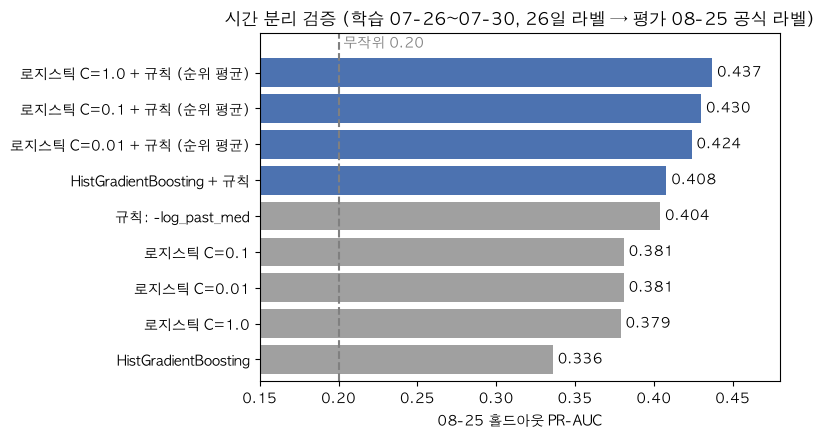

In [5]:
plot = result.iloc[1:].sort_values('PR-AUC')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot['방법'], plot['PR-AUC'], color=['#4C72B0' if '+' in s else '#A0A0A0' for s in plot['방법']])
ax.axvline(0.20, ls='--', c='gray'); ax.text(0.203, len(plot) - 0.3, '무작위 0.20', color='gray'); ax.set_ylim(-0.6, len(plot) + 0.1)
for i, v in enumerate(plot['PR-AUC']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center')
ax.set_xlim(0.15, 0.48); ax.set_xlabel('08-25 홀드아웃 PR-AUC')
ax.set_title('시간 분리 검증 (학습 07-26~07-30, 26일 라벨 → 평가 08-25 공식 라벨)')
plt.tight_layout(); plt.show()

**해석**
- 단순 규칙 `−log_past_med`만으로도 0.40. 라벨이 `log(미래) − log(과거)`라서 과거 중앙값이 낮은 채널이 평균 회귀로 상위 20%에 들기 쉽다.
- 트리 모델(HGB)은 표본 2천여 개 규모에서 과적합 → 로지스틱보다 확연히 낮음 (03번 노트북의 LightGBM 결과와 일치).
- 로지스틱 회귀와 규칙을 **순위 평균**하면 두 신호가 보완되어 가장 높다 (약 0.42).
- 리더보드 표본이 694행이라 ±0.03 흔들림이 있으므로, C 값은 홀드아웃 최고점이 아니라 중간값 **C = 0.1**로 고정한다.

## 4. 어떤 피처가 중요한가

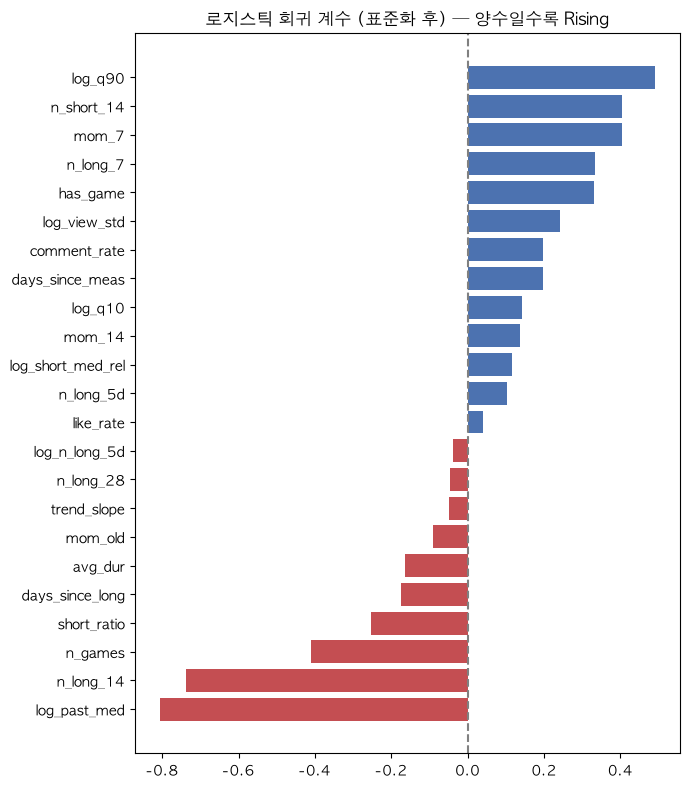

log_past_med   -0.807
n_long_14      -0.738
log_q90         0.491
n_games        -0.410
n_short_14      0.404
mom_7           0.403
n_long_7        0.332
has_game        0.331
dtype: float64

In [6]:
m = logreg(0.1).fit(tr[FEATURES], tr.target)
coef = pd.Series(m.named_steps['m'].coef_[0], index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(coef.index, coef.values, color=np.where(coef.values > 0, '#4C72B0', '#C44E52'))
ax.axvline(0, c='gray', ls='--')
ax.set_title('로지스틱 회귀 계수 (표준화 후) — 양수일수록 Rising')
plt.tight_layout(); plt.show()
coef.sort_values(key=abs, ascending=False).head(8).round(3)

## 5. 최종 학습 및 09-01 예측

최종 모델은 사용 가능한 라벨을 모두 쓴다.
- 자체 26일 라벨 07-26 ~ 08-05 (본선과 같은 창 길이)
- 공식 18일 라벨 08-11, 08-25 (09-01과 가장 가까운 시점의 채널 상태)

그 후 `0.5 × rank(모델 확률) + 0.5 × rank(−log_past_med)` 로 최종 점수를 만든다.

In [7]:
train_all = pd.concat([own, official], ignore_index=True)
final_model = logreg(0.1).fit(train_all[FEATURES], train_all.target)
print('학습 행 수:', len(train_all), '| 양성 비율:', round(train_all.target.mean(), 3))

sample = pd.read_csv(f'{RAW}/sample_submission.csv', encoding='utf-8-sig')   # 파일 앞 BOM 제거
sample['channel_id'] = sample.row_id.str.rsplit('_', n=1).str[0]

test = sample[['row_id', 'channel_id']].merge(make_features(D), on='channel_id', how='left')
print('09-01 피처 결측 채널 수 (log_past_med):', test.log_past_med.isna().sum())

proba = final_model.predict_proba(test[FEATURES])[:, 1]
test['prediction'] = blend(proba, test)
sub = sample[['row_id']].merge(test[['row_id', 'prediction']], on='row_id', how='left')
sub.describe()

학습 행 수: 6369 | 양성 비율: 0.201


09-01 피처 결측 채널 수 (log_past_med): 0


,prediction
count,694.000000
mean,0.500720
std,0.265053
min,0.005043
25%,0.293408
50%,0.507925
75%,0.719921
max,0.996398


## 6. 제출 전 검사 (제출 가이드 §3) 및 저장

In [8]:
assert list(sub.columns) == ['row_id', 'prediction']
assert len(sub) == len(sample) == 694
assert set(sub.row_id) == set(sample.row_id)
assert sub.row_id.is_unique
assert sub.prediction.notna().all() and np.isfinite(sub.prediction).all()
assert sub.prediction.between(0, 1).all()

FILE = '../submissions/submit_04_logreg_rankblend_fut26.csv'
sub.to_csv(FILE, index=False, encoding='utf-8')
print('저장 완료:', FILE, '| 크기', os.path.getsize(FILE), 'bytes')
pd.read_csv(FILE).head()

저장 완료: ../submissions/submit_04_logreg_rankblend_fut26.csv | 크기 38328 bytes


,row_id,prediction
0,UCl-VnCUwSxDr5zPu-YlDUYw_2026-09-01,0.616715
1,UCnkytUgy0CtWd06up9CjNxg_2026-09-01,0.046830
2,UCpI-AhCT02iQRGLC2ZcY0Jw_2026-09-01,0.244957
3,UC9otskL_kd-0CDib_5Lj-mQ_2026-09-01,0.477666
4,UCSzHok6X5qXEO7cjvVnE62g_2026-09-01,0.325648


## 7. 정리

| 단계 | 결정 | 근거 |
|---|---|---|
| 라벨 창 | 자체 라벨을 **26일**로 생성 | 본선 정답 구간이 18일 → 26일로 길어짐 |
| 학습 기준일 | 07-26 ~ 08-05 + 공식 08-11, 08-25 | 이력이 짧은 이른 기준일은 피처 분포가 09-01과 다름 |
| 검증 | 07-26~07-30 학습 → 08-25 평가 | 라벨 창이 겹치지 않는 유일한 시간 분리 |
| 모델 | 로지스틱 회귀 (C=0.1, class_weight=balanced) | 트리 모델 대비 일관되게 우수, 표본 규모에 맞음 |
| 최종 점수 | 모델 순위 + 과거 중앙값 역순위 평균 | 평균 회귀 신호가 가장 강하고, 모델이 나머지를 보완 |

**한계**: 694행 리더보드는 ±0.03 흔들림이 있고, 26일 창 검증 라벨을 깨끗하게 만들 수 있는 기준일이 적다.